In [1]:
import pandas as pd
import numpy as np
from scipy.stats import f_oneway
import matplotlib.pyplot as plt

In [2]:
from google.colab import files
uploaded = files.upload()

Saving raw data1.csv to raw data1.csv


**Loading dataset**

In [3]:
df = pd.read_csv('raw data1.csv')

df.head()

,Product_ID,Sale_Date,Sales_Rep,Region,Sales_Amount,Quantity_Sold,Product_Category,Unit_Cost,Unit_Price,Customer_Type,Discount,Payment_Method,Sales_Channel,Region_and_Sales_Rep
0,1052,03-02-2023,Bob,North,5053.97,18,Furniture,152.75,267.22,Returning,0.09,Cash,Online,North-Bob
1,1093,21-04-2023,Bob,West,4384.02,17,Furniture,3816.39,4209.44,Returning,0.11,Cash,Retail,West-Bob
2,1015,21-09-2023,David,South,4631.23,30,Food,261.56,371.40,Returning,0.20,Bank Transfer,Retail,South-David
3,1072,24-08-2023,Bob,South,2167.94,39,Clothing,4330.03,4467.75,New,0.02,Credit Card,Retail,South-Bob
4,1061,24-03-2023,Charlie,East,3750.20,13,Electronics,637.37,692.71,New,0.08,Credit Card,Online,East-Charlie


**Check Categories**

In [4]:
df['Product_Category'].unique()

array(['Furniture', 'Food', 'Clothing', 'Electronics'], dtype=object)

**Separate Sales by category**

In [5]:
electronics = df[df['Product_Category']=='Electronics']['Sales_Amount']
furniture = df[df['Product_Category']=='Furniture']['Sales_Amount']
clothing = df[df['Product_Category']=='Clothing']['Sales_Amount']
food = df[df['Product_Category']=='Food']['Sales_Amount']

**Perform ANOVA Test**

In [6]:
stat, p_value = f_oneway(electronics, furniture, clothing, food)

print("P-value:", p_value)

P-value: 0.28268113249547605


**Interpret Result**

In [7]:
if p_value < 0.05:
    print("Reject Null Hypothesis")
    print("Product Category significantly affects Sales Amount")
else:
    print("Fail to Reject Null Hypothesis")
    print("Product Category does not significantly affect Sales Amount")

Fail to Reject Null Hypothesis
Product Category does not significantly affect Sales Amount


**Visualization**

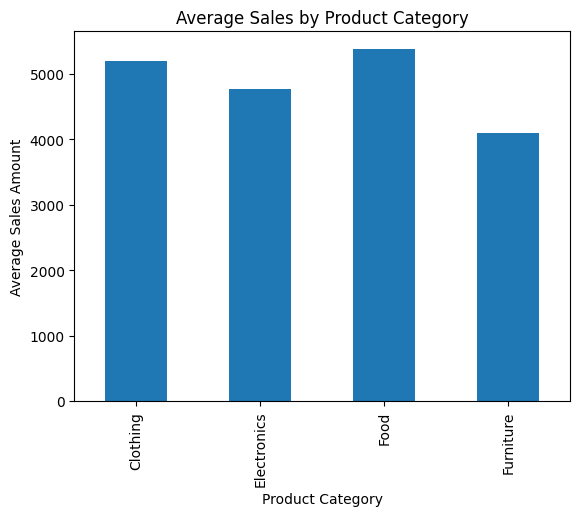

In [8]:
category_sales = df.groupby('Product_Category')['Sales_Amount'].mean()

category_sales.plot(kind='bar')

plt.title("Average Sales by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Average Sales Amount")

plt.show()